<a href="https://colab.research.google.com/github/seungah-lab/Intelligence-powered-epidemiology/blob/main/Week_4_%EB%A6%BF%EC%A7%80%2C_%EB%9D%BC%EC%8F%98%2C_%EC%97%98%EB%9D%BC%EC%8A%A4%ED%8B%B1%EB%84%B7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 규제(Regularization) 방법 적용해보기

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

##### 1. 데이터 생성 (2차 다항식 기반 비선형 데이터)

In [2]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

##### 2. 모델 리스트 정의 (고차항 다항 회귀 + 규제)

In [3]:
# Degree=10으로 설정하여 과적합을 유도한 뒤, 규제의 효과를 확인합니다.
degree = 10
models = [
    ("Linear (No Reg)", LinearRegression()),
    ("Ridge (L2)", Ridge(alpha=1, solver="cholesky")),
    ("Lasso (L1)", Lasso(alpha=0.1)),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5))
]

##### 3. 시각화 준비

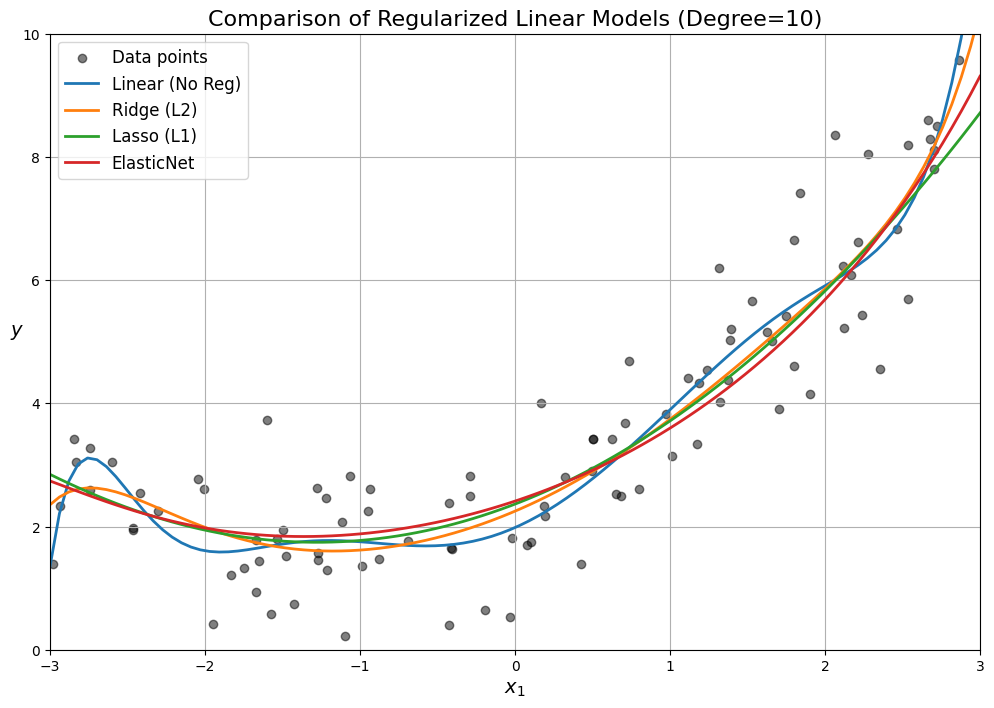

In [4]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
plt.figure(figsize=(12, 8))
plt.scatter(X, y, color="black", alpha=0.5, label="Data points")

for name, model in models:
    # 파이프라인 구성: 다항 특성 추가 -> 스케일링 -> 모델 훈련
    # 규제 모델은 특성 스케일에 민감하므로 StandardScaler가 필수입니다.
    model_pipeline = Pipeline([
        ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
        ("std_scaler", StandardScaler()),
        ("reg_model", model),
    ])

    model_pipeline.fit(X, y)
    y_new_predict = model_pipeline.predict(X_new)

    plt.plot(X_new, y_new_predict, label=name, linewidth=2)

plt.axis([-3, 3, 0, 10])
plt.xlabel("$x_1$", fontsize=14)
plt.ylabel("$y$", rotation=0, fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.title(f"Comparison of Regularized Linear Models (Degree={degree})", fontsize=16)
plt.grid(True)
plt.show()

##### 4. 각 모델의 계수 확인 (변수 선택 효과 관찰)

In [ ]:
for name, model in models:
    model_pipeline = Pipeline([
        ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
        ("std_scaler", StandardScaler()),
        ("reg_model", model),
    ])
    model_pipeline.fit(X, y)
    weights = model_pipeline.named_steps['reg_model'].coef_
    print(f"[{name}] weights (first 5):\n{weights.flatten()[:5]}\n")